## 2️⃣Phase 2: Feature Engineering
#### 1. import cleaned data
#### 2. encoding
#### 3. scaling
#### 4. feature creation
#### 5. transformations
#### 6. remove correlations

## 1} Imports

In [46]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

## 2} Load

In [47]:
# Load cleaned data

df = pd.read_csv("/content/cleaned_DataSet..csv")

df.head()

,Order,PID,MS SubClass,MS Zoning,Lot Frontage,Lot Area,Street,Lot Shape,Land Contour,Utilities,...,Enclosed Porch,3Ssn Porch,Screen Porch,Pool Area,Misc Val,Mo Sold,Yr Sold,Sale Type,Sale Condition,SalePrice
0,1,526301100,20,RL,141.0,31770,Pave,IR1,Lvl,AllPub,...,0,0,0,0,0,5,2010,WD,Normal,215000
1,2,526350040,20,RH,80.0,11622,Pave,Reg,Lvl,AllPub,...,0,0,120,0,0,6,2010,WD,Normal,105000
2,3,526351010,20,RL,81.0,14267,Pave,IR1,Lvl,AllPub,...,0,0,0,0,12500,6,2010,WD,Normal,172000
3,4,526353030,20,RL,93.0,11160,Pave,Reg,Lvl,AllPub,...,0,0,0,0,0,4,2010,WD,Normal,244000
4,5,527105010,60,RL,74.0,13830,Pave,IR1,Lvl,AllPub,...,0,0,0,0,0,3,2010,WD,Normal,189900


## 3} Shape

In [48]:
print("Shape:", df.shape)

Shape: (2930, 78)


## 4} Encoding

In [49]:
# One-hot encoding

# Convert categorical columns to numeric
df = pd.get_dummies(df, columns=["Neighborhood", "MS Zoning"], drop_first=True)

Ordinal encoding

In [50]:
# Overall Qual already ordered (1 → 10)
df["Overall Qual"] = df["Overall Qual"].astype(int)

## 5} Split

In [51]:
from sklearn.model_selection import train_test_split

# Split to Train and Test
train_df, test_df = train_test_split(df, test_size=0.2, random_state=42)

## 6} Scaling

In [52]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

num_cols = ["Lot Area", "Gr Liv Area"]

# fit on training only
train_df[num_cols] = scaler.fit_transform(train_df[num_cols])

# apply on test
test_df[num_cols] = scaler.transform(test_df[num_cols])

### To work in the Training JUST!

In [53]:
df = train_df

## 7} Create Features

In [54]:
# Ratio feature

# Avoid division by zero
df["price_per_sqft"] = df["SalePrice"] / df["Gr Liv Area"].replace(0, 1)

In [55]:
# Total bathrooms

df["total_bathrooms"] = df["Full Bath"] + (0.5 * df["Half Bath"])

In [56]:
# Age of the house at sale

df["age_at_sale"] = df["Yr Sold"] - df["Year Built"]

#### Why create features?

> - Some columns alone are not enough  
> - Combining them gives better meaning

## 8} Interaction Feature

In [57]:
df["quality_x_area"] = df["Overall Qual"] * df["Gr Liv Area"]

## 9} Log Transform

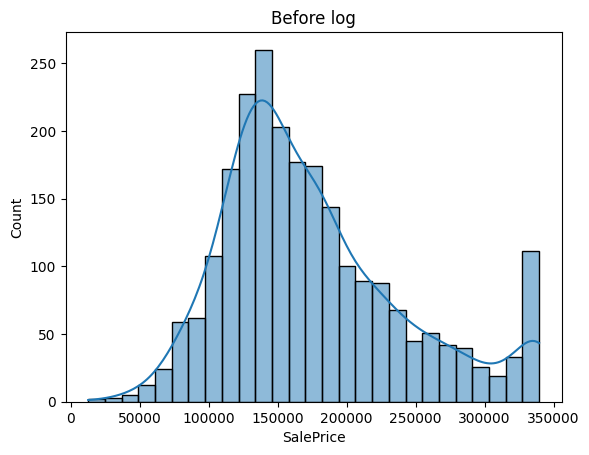

In [58]:
# Before

sns.histplot(df["SalePrice"], kde=True)
plt.title("Before log")
plt.show()

In [59]:
# Apply log

df["SalePrice_log"] = np.log1p(df["SalePrice"])

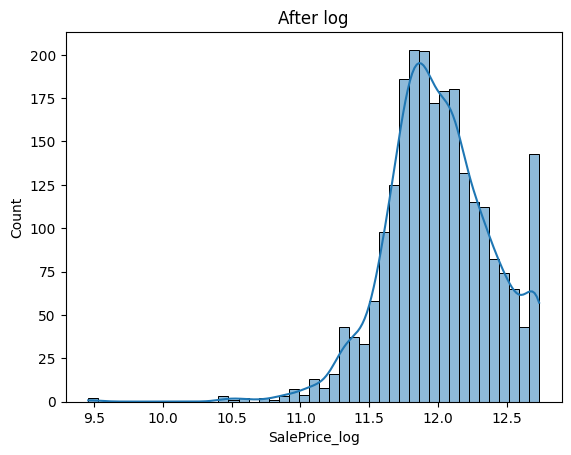

In [60]:
# After

sns.histplot(df["SalePrice_log"], kde=True)
plt.title("After log")
plt.show()

#### Why log?

> - SalePrice is skewed  
> - log makes the distribution more balanced

# 10} Binning

In [61]:
# Age groups

df["age_group"] = pd.cut(
    df["age_at_sale"],
    bins=[0, 10, 30, 100],
    labels=["New", "Recent", "Old"]
)

## 11} Correlation

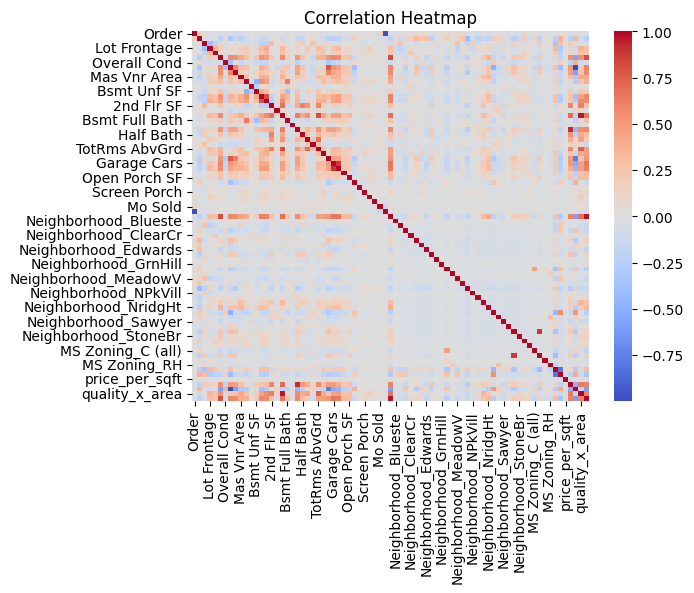

In [62]:
# Correlation matrix

corr = df.corr(numeric_only=True)

# Heatmap

sns.heatmap(corr, cmap="coolwarm")
plt.title("Correlation Heatmap")
plt.show()

#### Why remove correlated features?

> - Some columns give the same information  
> - I removed one based on correlation heatmap

## 12} Drop highly correlated

In [63]:
# Drop one of the highly correlated columns

df = df.drop(columns=["Garage Cars"])

## 13} Save

In [64]:
df.to_csv("features_DataSet.csv", index=False)

## done🌟

> - Encoded categorical features
>
> - Scaled numerical columns
> - Created new meaningful features
> - Applied log transformation
> - Reduced redundant features